# Notebook 08c — XGBoost: Weather Effects on Cycling Demand
Gradient boosted trees as a drop-in replacement for the GAM:
same data, same target variable, same train/test split.
SHAP values replace GAM partial dependence plots for interpretability.

## 0. Imports & Setup

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost", "shap"])

import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

ROOT      = Path().resolve().parent
PROCESSED = ROOT / "data" / "processed"
FIGS      = ROOT / "outputs" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

COLORS = {
    "commuter" : "#2196F3",
    "mixed"    : "#FFC107",
    "leisure"  : "#F44336",
}

panel = pd.read_parquet(PROCESSED / "analysis_panel.parquet")

site_cls = pd.read_parquet(PROCESSED / "site_classification.parquet")[["site ID", "commute_score", "site_type"]]
panel = panel.merge(site_cls, on="site ID", how="left")
panel["site_type"] = panel["site_type"].fillna("unclassified")

panel_good = panel[
    (panel["low_coverage"] == False) &
    (panel["aantal"].notna()) &
    (panel["temp_avg"].notna())
].copy()
panel_good["date"] = pd.to_datetime(panel_good["date"])

print(f"Date range : {panel_good['date'].min().date()}  \u2192  {panel_good['date'].max().date()}")
print(f"Total rows : {len(panel_good):,}")
print("\nRows per year:")
print(panel_good['date'].dt.year.value_counts().sort_index().to_string())
print("\nsite_type distribution:")
print(panel_good['site_type'].value_counts().to_string())

Date range : 2023-01-01  →  2025-12-31
Total rows : 144,338

Rows per year:
date
2023    47836
2024    48351
2025    48151

site_type distribution:
site_type
mixed       48735
commuter    47956
leisure     47647


## 0b. Train-only IQR Outlier Audit

Calculate per-site upper fences (`Q3 + 3 × IQR`) using **train data only** (2023–2024).  
Stations where `IQR = 0` (sparse/mostly-zero counters) are excluded from flagging.

In [2]:
def site_stats(x):
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    return pd.Series({"q1": q1, "q3": q3, "iqr": iqr,
                      "median": x.median(), "upper_fence": q3 + 3 * iqr})

_train_for_iqr = panel_good[panel_good["date"].dt.year.isin([2023, 2024])].copy()
_stats = _train_for_iqr.groupby("site ID")["aantal"].apply(site_stats).unstack()
_train_for_iqr = _train_for_iqr.merge(_stats, on="site ID")

_outliers = _train_for_iqr[
    (_train_for_iqr["aantal"] > _train_for_iqr["upper_fence"]) &
    (_train_for_iqr["iqr"] > 0)
].copy()
_outliers["ratio"] = (_outliers["aantal"] / _outliers["median"]).round(1)

print(f"Total flagged (Q3 + 3\u00d7IQR, train 2023\u20132024): {len(_outliers)}")

_candidates = _outliers[_outliers["ratio"] >= 5][
    ["site ID", "naam", "date", "aantal", "median", "upper_fence", "ratio"]
].copy()

_site_max = _candidates.groupby("site ID")["ratio"].max().rename("site_max")
_candidates = (_candidates
    .merge(_site_max, on="site ID")
    .sort_values(["site_max", "site ID", "ratio"], ascending=[False, True, False])
    .drop(columns="site_max")
)

print()
print("=" * 80)
print("CANDIDATES WITH RATIO \u2265 5\u00d7 MEDIAN  (grouped by site, \u2193 ratio)")
print("=" * 80)
_current_site = None
for _, row in _candidates.iterrows():
    if row["site ID"] != _current_site:
        _current_site = row["site ID"]
        site_n = _candidates[_candidates["site ID"] == _current_site].shape[0]
        print(f"\n  site {int(row['site ID']):<4}  {row['naam']}  [{site_n} flagged date(s)]")
    print(f"    {str(row['date'])[:10]}  aantal={int(row['aantal']):>6}  "
          f"median={row['median']:>6.1f}  fence={row['upper_fence']:>8.1f}  ratio={row['ratio']:.1f}x")

print()
print("=" * 80)
print("STATIONS WITH IQR=0 (excluded \u2014 sparse/mostly-zero counters)")
print("=" * 80)
_zero_iqr_sites = _stats[_stats["iqr"] == 0].index.tolist()
for sid in _zero_iqr_sites:
    _rows = _train_for_iqr[_train_for_iqr["site ID"] == sid]
    naam = _rows["naam"].iloc[0] if len(_rows) else "?"
    n_nonzero = (_rows["aantal"] > 0).sum()
    print(f"  site {sid:<4} {naam[:32]:<32}  nonzero={n_nonzero}/{len(_rows)}")

Total flagged (Q3 + 3×IQR, train 2023–2024): 125

CANDIDATES WITH RATIO ≥ 5× MEDIAN  (grouped by site, ↓ ratio)

  site 105   St. pieters leeuw teller 2  [1 flagged date(s)]
    2023-03-03  aantal=   807  median=   0.0  fence=   232.0  ratio=infx

  site 85    Asse teller 1  [3 flagged date(s)]
    2024-07-25  aantal=  4823  median=  82.0  fence=   268.0  ratio=58.8x
    2024-07-21  aantal=   904  median=  82.0  fence=   268.0  ratio=11.0x
    2024-07-07  aantal=   660  median=  82.0  fence=   268.0  ratio=8.0x

  site 83    Beersel teller 2  [16 flagged date(s)]
    2024-03-31  aantal=  1796  median=  46.0  fence=   141.0  ratio=39.0x
    2024-03-19  aantal=  1748  median=  46.0  fence=   141.0  ratio=38.0x
    2024-03-30  aantal=  1720  median=  46.0  fence=   141.0  ratio=37.4x
    2024-04-06  aantal=  1534  median=  46.0  fence=   141.0  ratio=33.3x
    2024-03-29  aantal=  1443  median=  46.0  fence=   141.0  ratio=31.4x
    2024-04-01  aantal=  1217  median=  46.0  fence=   141.0

## 0c. Outlier Blacklist, Event Flags & Train/Test Split

Based on the IQR audit above, classify each candidate:
- **`remove_dates`** — likely data/sensor errors: set `aantal` to NaN
- **`event_dates`** — confirmed real events: keep value, flag with `is_event_day = 1`

In [3]:
remove_dates = [
    (105, '2023-03-03'),
    (85,  '2024-07-25'),
    (20,  '2024-06-02'),
    (140, '2024-07-13'),
    (129, '2024-08-12'),
    (78,  '2023-07-01'),
    (50,  '2024-09-18'),
    (94,  '2023-08-20'),
    (33,  '2023-01-20'),
    (81,  '2024-08-18'),
    (83,  '2024-03-19'),
    (83,  '2024-03-27'), (83,  '2024-03-28'), (83,  '2024-03-29'),
    (83,  '2024-03-30'), (83,  '2024-03-31'), (83,  '2024-04-01'),
    (83,  '2024-04-02'), (83,  '2024-04-03'), (83,  '2024-04-04'),
    (83,  '2024-04-05'), (83,  '2024-04-06'), (83,  '2024-04-07'),
    (83,  '2024-04-08'), (83,  '2024-04-09'), (83,  '2024-04-10'),
]

event_dates = [
    (70,  '2023-09-16'), (70,  '2024-09-21'),
    (70,  '2025-09-20'), (70,  '2025-09-21'),
    (85,  '2024-07-07'), (85,  '2024-07-21'),
    (72,  '2024-05-08'), (51,  '2024-05-08'),
    (43,  '2023-05-28'), (44,  '2023-05-28'),
    (28,  '2024-04-06'), (28,  '2024-04-13'), (28,  '2024-04-14'),
    (28,  '2023-04-30'), (28,  '2023-05-01'), (28,  '2023-05-04'),
    (34,  '2024-04-06'), (34,  '2023-04-30'), (34,  '2023-06-03'),
    (14,  '2023-09-24'), (14,  '2024-09-22'),
    (48,  '2024-09-18'), (48,  '2024-09-19'), (48,  '2024-09-20'),
    (48,  '2024-09-21'), (48,  '2024-09-22'),
]

remove_set = set((s, d) for s, d in remove_dates)
event_set  = set((s, d) for s, d in event_dates)

remove_mask = panel_good.apply(
    lambda row: (row['site ID'], str(row['date'])[:10]) in remove_set, axis=1
)
panel_good.loc[remove_mask, 'aantal'] = np.nan
print(f'Removed {remove_mask.sum()} extreme outlier rows')

event_mask = panel_good.apply(
    lambda row: (row['site ID'], str(row['date'])[:10]) in event_set, axis=1
)
panel_good['is_event_day'] = event_mask.astype(int)
print(f'Flagged {event_mask.sum()} recurring event days')

print("\n" + "\u2500" * 40)
train = panel_good[panel_good["date"].dt.year.isin([2023, 2024])].copy()
test  = panel_good[panel_good["date"].dt.year == 2025].copy()

site_log_mean = (
    train.groupby('site ID')['aantal']
    .apply(lambda x: np.log1p(x.mean()))
    .reset_index()
    .rename(columns={'aantal': 'site_offset'})
)
train      = train.merge(site_log_mean, on='site ID', how='left')
test       = test.merge(site_log_mean, on='site ID', how='left')
panel_good = panel_good.merge(site_log_mean, on='site ID', how='left')

print(f"Train size : {len(train):,} rows (2023\u20132024)")
print(f"Test size  : {len(test):,} rows (2025)")

Removed 26 extreme outlier rows


Flagged 26 recurring event days

────────────────────────────────────────


Train size : 96,187 rows (2023–2024)
Test size  : 48,151 rows (2025)


## 1. Feature Engineering

In [4]:
for col in ["is_weekend", "is_public_holiday", "is_school_holiday", "is_event_day"]:
    train[col] = train[col].astype(int)
    test[col]  = test[col].astype(int)
    panel_good[col] = panel_good[col].astype(int)

ALL_FEATURES = [
    "temp_avg", "precip_total", "wind_avg",
    "sunshine_min", "humidity_avg",
    "temp_avg_lag1", "precip_total_lag1", "wind_avg_lag1",
    "dayofweek",
    "month",
    "is_weekend", "is_public_holiday", "is_school_holiday", "is_event_day",
]

print(f"Features ({len(ALL_FEATURES)}): {ALL_FEATURES}")
print(f"Train shape: {train.shape} |  Test shape: {test.shape}")

Features (14): ['temp_avg', 'precip_total', 'wind_avg', 'sunshine_min', 'humidity_avg', 'temp_avg_lag1', 'precip_total_lag1', 'wind_avg_lag1', 'dayofweek', 'month', 'is_weekend', 'is_public_holiday', 'is_school_holiday', 'is_event_day']
Train shape: (96187, 58) |  Test shape: (48151, 58)


## 2. Prepare Feature Matrix

XGBoost handles raw (unscaled) features natively — no StandardScaler needed.

In [5]:
def make_X_y_with_offset(df, features):
    cols = features + ["aantal", "site_offset"]
    df_clean = df[cols].dropna()
    X     = df_clean[features].values.astype(float)
    y_raw = df_clean["aantal"].values.astype(float)
    y_adj = np.log1p(y_raw) - df_clean["site_offset"].values
    return X, y_adj, y_raw, df_clean

X_train_full, y_train_full, y_train_raw_full, train_clean_full = make_X_y_with_offset(train, ALL_FEATURES)
X_test_full,  y_test_full,  y_test_raw_full,  test_clean_full  = make_X_y_with_offset(test,  ALL_FEATURES)

print(f"X_train : {X_train_full.shape}  |  y_train : {y_train_full.shape}")
print(f"X_test  : {X_test_full.shape}   |  y_test  : {y_test_full.shape}")
print(f"y_train_raw \u2014 mean: {y_train_raw_full.mean():.1f}, std: {y_train_raw_full.std():.1f}, "
      f"min: {y_train_raw_full.min():.0f}, max: {y_train_raw_full.max():.0f}")

X_train : (96038, 14)  |  y_train : (96038,)
X_test  : (48151, 14)   |  y_test  : (48151,)
y_train_raw — mean: 482.5, std: 632.8, min: 0, max: 10109


## 3. Model A — Full XGBoost (all stations)

In [6]:
def evaluate(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    print(f"  {label:<12}: MAE={mae:.1f}  RMSE={rmse:.1f}  R\u00b2={r2:.3f}")
    return mae, rmse, r2

XGB_PARAMS = dict(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    reg_alpha=0.1,
    reg_lambda=1.0,
    early_stopping_rounds=50,
    eval_metric="rmse",
    random_state=42,
)

xgb_full = XGBRegressor(**XGB_PARAMS)
xgb_full.fit(
    X_train_full, y_train_full,
    eval_set=[(X_test_full, y_test_full)],
    verbose=False,
)

offset_test_full = test_clean_full["site_offset"].values
y_pred_full_raw  = xgb_full.predict(X_test_full)
y_pred_full      = np.clip(np.expm1(y_pred_full_raw + offset_test_full), 0, None)

print(f"Best iteration: {xgb_full.best_iteration}")
print("\n" + "=" * 52)
print("MODEL A \u2014 Full XGBoost Performance")
print("=" * 52)
test_mae, test_rmse, test_r2 = evaluate(y_test_raw_full, y_pred_full, "Test")
print("=" * 52)

Best iteration: 123

MODEL A — Full XGBoost Performance
  Test        : MAE=152.7  RMSE=326.3  R²=0.787


## 4. Model B — Commuter XGBoost

In [7]:
train_c = train[train["site_type"] == "commuter"].copy()
test_c  = test[test["site_type"]   == "commuter"].copy()

X_train_c, y_train_c, y_train_c_raw, train_clean_c = make_X_y_with_offset(train_c, ALL_FEATURES)
X_test_c,  y_test_c,  y_test_c_raw,  test_clean_c  = make_X_y_with_offset(test_c,  ALL_FEATURES)

xgb_commuter = XGBRegressor(**XGB_PARAMS)
xgb_commuter.fit(
    X_train_c, y_train_c,
    eval_set=[(X_test_c, y_test_c)],
    verbose=False,
)

offset_test_c = test_clean_c["site_offset"].values
y_pred_c_raw  = xgb_commuter.predict(X_test_c)
y_pred_c      = np.clip(np.expm1(y_pred_c_raw + offset_test_c), 0, None)

print(f"Best iteration: {xgb_commuter.best_iteration}")
print("Commuter XGBoost:")
mae_c, rmse_c, r2_c = evaluate(y_test_c_raw, y_pred_c, "Test")

Best iteration: 69
Commuter XGBoost:
  Test        : MAE=136.4  RMSE=257.7  R²=0.775


## 5. Model C — Leisure XGBoost

In [8]:
train_l = train[train["site_type"] == "leisure"].copy()
test_l  = test[test["site_type"]   == "leisure"].copy()

X_train_l, y_train_l, y_train_l_raw, train_clean_l = make_X_y_with_offset(train_l, ALL_FEATURES)
X_test_l,  y_test_l,  y_test_l_raw,  test_clean_l  = make_X_y_with_offset(test_l,  ALL_FEATURES)

xgb_leisure = XGBRegressor(**XGB_PARAMS)
xgb_leisure.fit(
    X_train_l, y_train_l,
    eval_set=[(X_test_l, y_test_l)],
    verbose=False,
)

offset_test_l = test_clean_l["site_offset"].values
y_pred_l_raw  = xgb_leisure.predict(X_test_l)
y_pred_l      = np.clip(np.expm1(y_pred_l_raw + offset_test_l), 0, None)

print(f"Best iteration: {xgb_leisure.best_iteration}")
print("Leisure XGBoost:")
mae_l, rmse_l, r2_l = evaluate(y_test_l_raw, y_pred_l, "Test")

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(f"{'Metric':<6} | {'Full XGB':>10} | {'Commuter XGB':>13} | {'Leisure XGB':>12}")
print("-" * 60)
print(f"{'MAE':<6} | {test_mae:>10.1f} | {mae_c:>13.1f} | {mae_l:>12.1f}")
print(f"{'RMSE':<6} | {test_rmse:>10.1f} | {rmse_c:>13.1f} | {rmse_l:>12.1f}")
_r2 = "R\u00b2"
print(f"{_r2:<6} | {test_r2:>10.3f} | {r2_c:>13.3f} | {r2_l:>12.3f}")
print("=" * 60)

GAM_R2 = {"Full": 0.784, "Commuter": 0.779, "Leisure": 0.626}
print("\n" + "=" * 60)
print("GAM vs XGBOOST COMPARISON (Test Set R\u00b2)")
print("=" * 60)
_h1, _h2, _h3 = 'GAM R\u00b2', 'XGBoost R\u00b2', '\u0394 R\u00b2'
print(f"{'Model':<10} | {_h1:>8} | {_h2:>11} | {_h3:>8}")
print("-" * 60)
for name, xgb_r2, gam_r2 in [("Full", test_r2, GAM_R2["Full"]),
                               ("Commuter", r2_c, GAM_R2["Commuter"]),
                               ("Leisure", r2_l, GAM_R2["Leisure"])]:
    print(f"{name:<10} | {gam_r2:>8.3f} | {xgb_r2:>11.3f} | {xgb_r2 - gam_r2:>+8.3f}")
print("=" * 60)

Best iteration: 120
Leisure XGBoost:
  Test        : MAE=174.2  RMSE=376.4  R²=0.663

MODEL COMPARISON
Metric |   Full XGB |  Commuter XGB |  Leisure XGB
------------------------------------------------------------
MAE    |      152.7 |         136.4 |        174.2
RMSE   |      326.3 |         257.7 |        376.4
R²     |      0.787 |         0.775 |        0.663

GAM vs XGBOOST COMPARISON (Test Set R²)
Model      |   GAM R² |  XGBoost R² |     Δ R²
------------------------------------------------------------
Full       |    0.784 |       0.787 |   +0.003
Commuter   |    0.779 |       0.775 |   -0.004
Leisure    |    0.626 |       0.663 |   +0.037


## 6. SHAP Analysis

SHAP values computed on 3000 random test observations for speed.

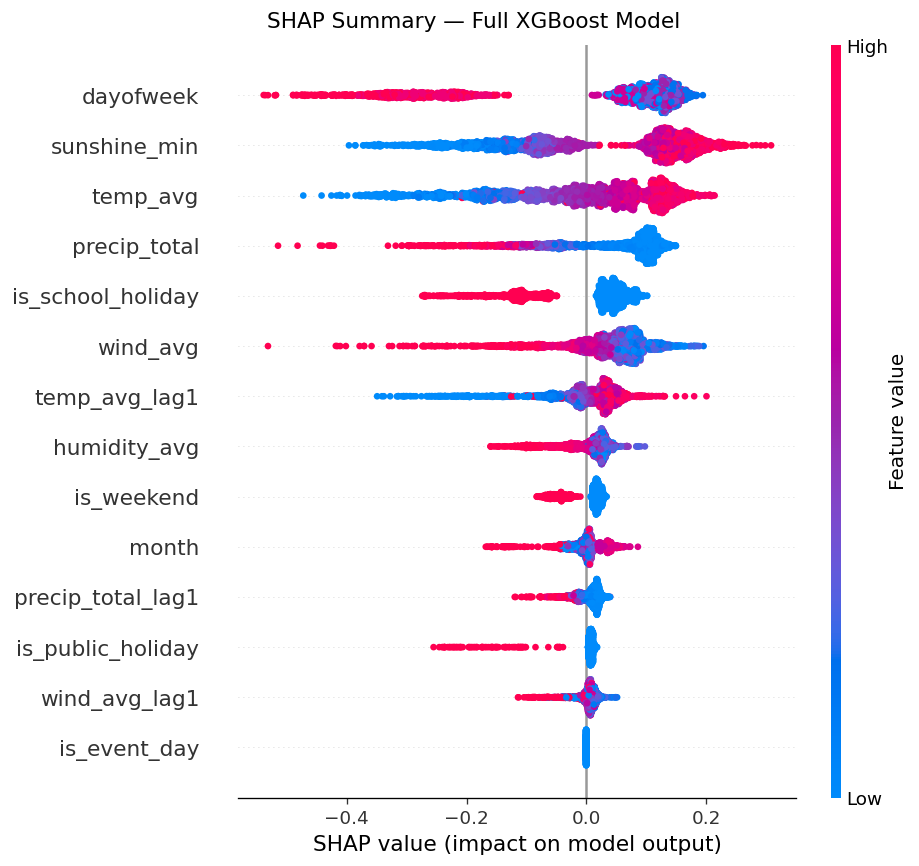

08c_shap_summary_full.png saved.


In [9]:
N_SHAP = 3000
rng = np.random.default_rng(42)

idx_shap_full  = rng.choice(len(X_test_full), size=min(N_SHAP, len(X_test_full)), replace=False)
X_shap_full    = X_test_full[idx_shap_full]

explainer_full   = shap.TreeExplainer(xgb_full)
shap_values_full = explainer_full.shap_values(X_shap_full)

# Fig A — SHAP summary plot (full model)
shap.summary_plot(shap_values_full, X_shap_full, feature_names=ALL_FEATURES, show=False)
fig_a = plt.gcf()
fig_a.suptitle("SHAP Summary \u2014 Full XGBoost Model", fontsize=13, y=1.01)
fig_a.savefig(FIGS / "08c_shap_summary_full.png", dpi=150, bbox_inches="tight")
plt.show()
print("08c_shap_summary_full.png saved.")

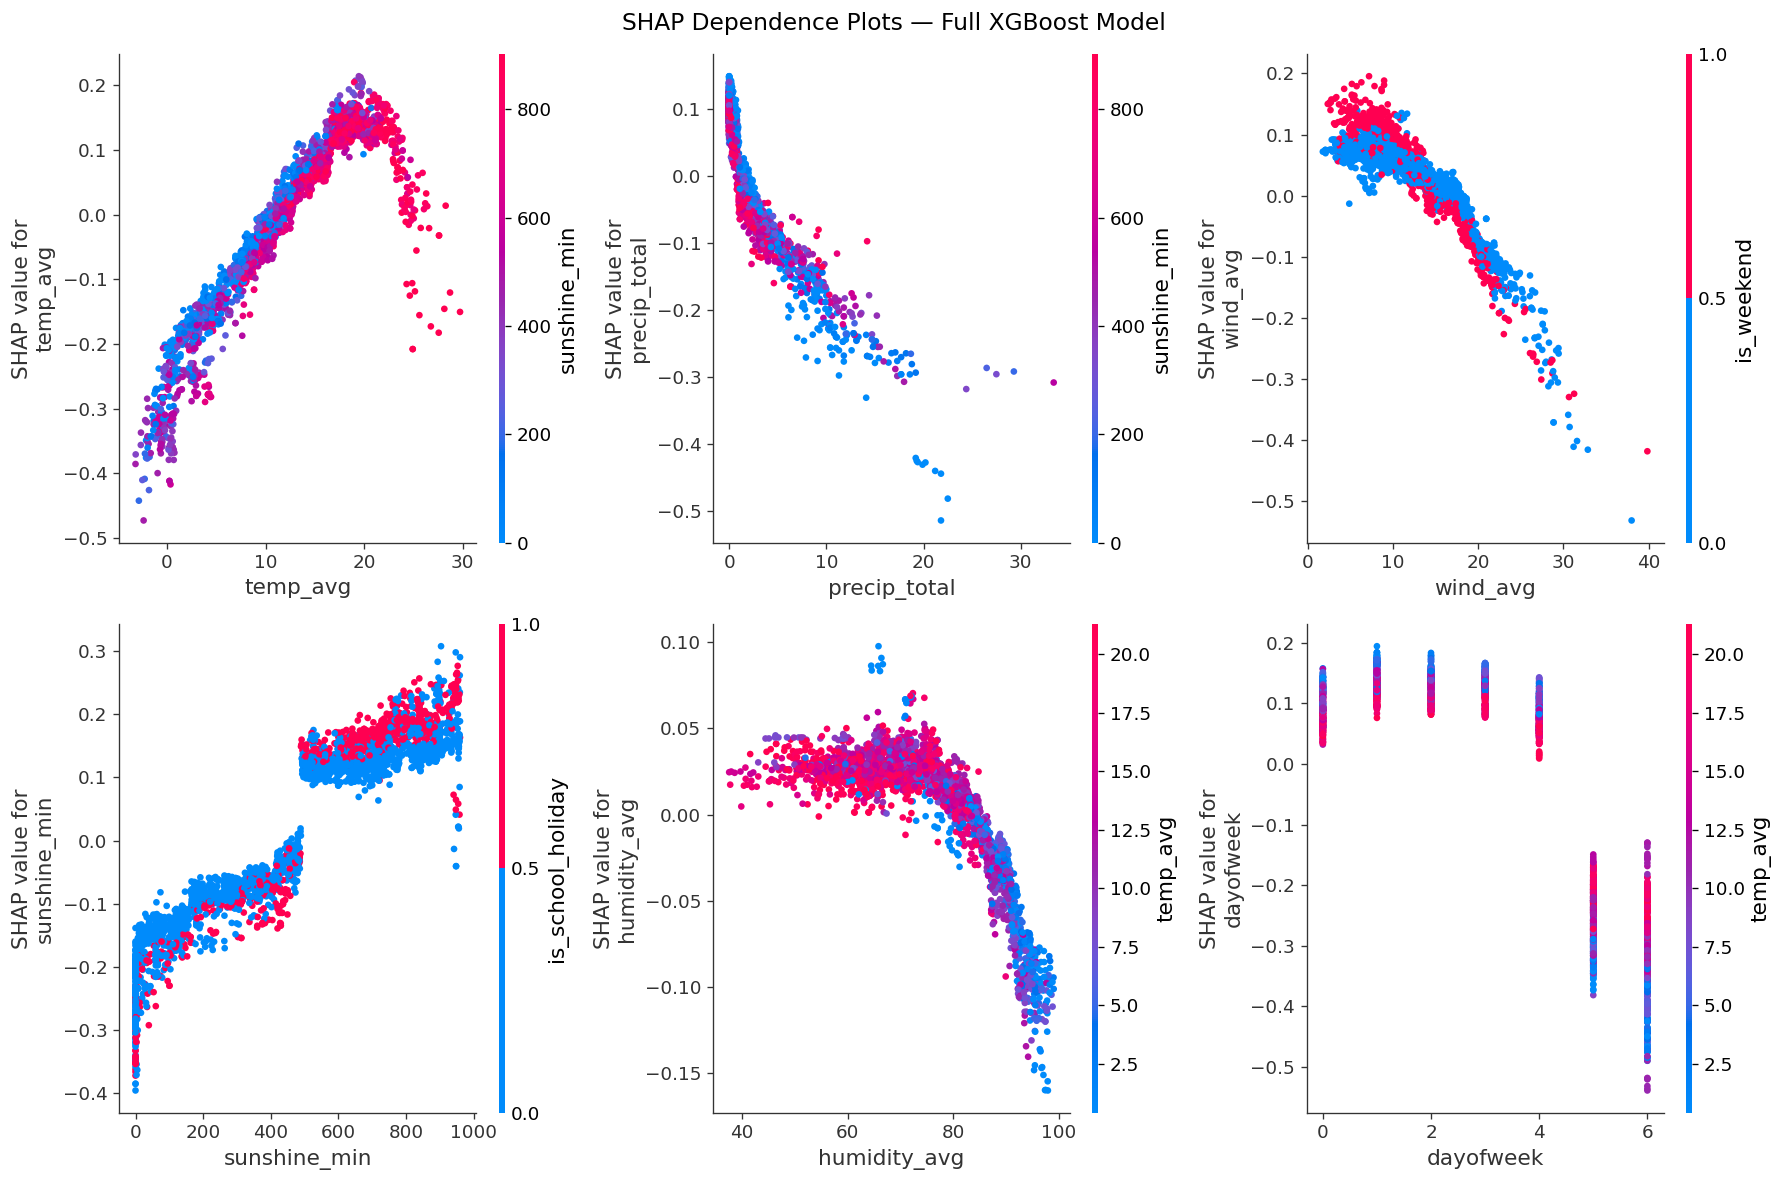

08c_shap_dependence_full.png saved.


In [10]:
# Fig B — SHAP dependence plots (2×3 grid, full model)
dep_features = ["temp_avg", "precip_total", "wind_avg",
                "sunshine_min", "humidity_avg", "dayofweek"]

fig_b, axes_b = plt.subplots(2, 3, figsize=(15, 10))
axes_flat = axes_b.flatten()

X_shap_df = pd.DataFrame(X_shap_full, columns=ALL_FEATURES)
for i, feat in enumerate(dep_features):
    shap.dependence_plot(
        feat,
        shap_values_full,
        X_shap_df,
        ax=axes_flat[i],
        show=False,
    )

fig_b.suptitle("SHAP Dependence Plots \u2014 Full XGBoost Model", fontsize=14)
fig_b.tight_layout()
fig_b.savefig(FIGS / "08c_shap_dependence_full.png", dpi=150, bbox_inches="tight")
plt.show()
print("08c_shap_dependence_full.png saved.")

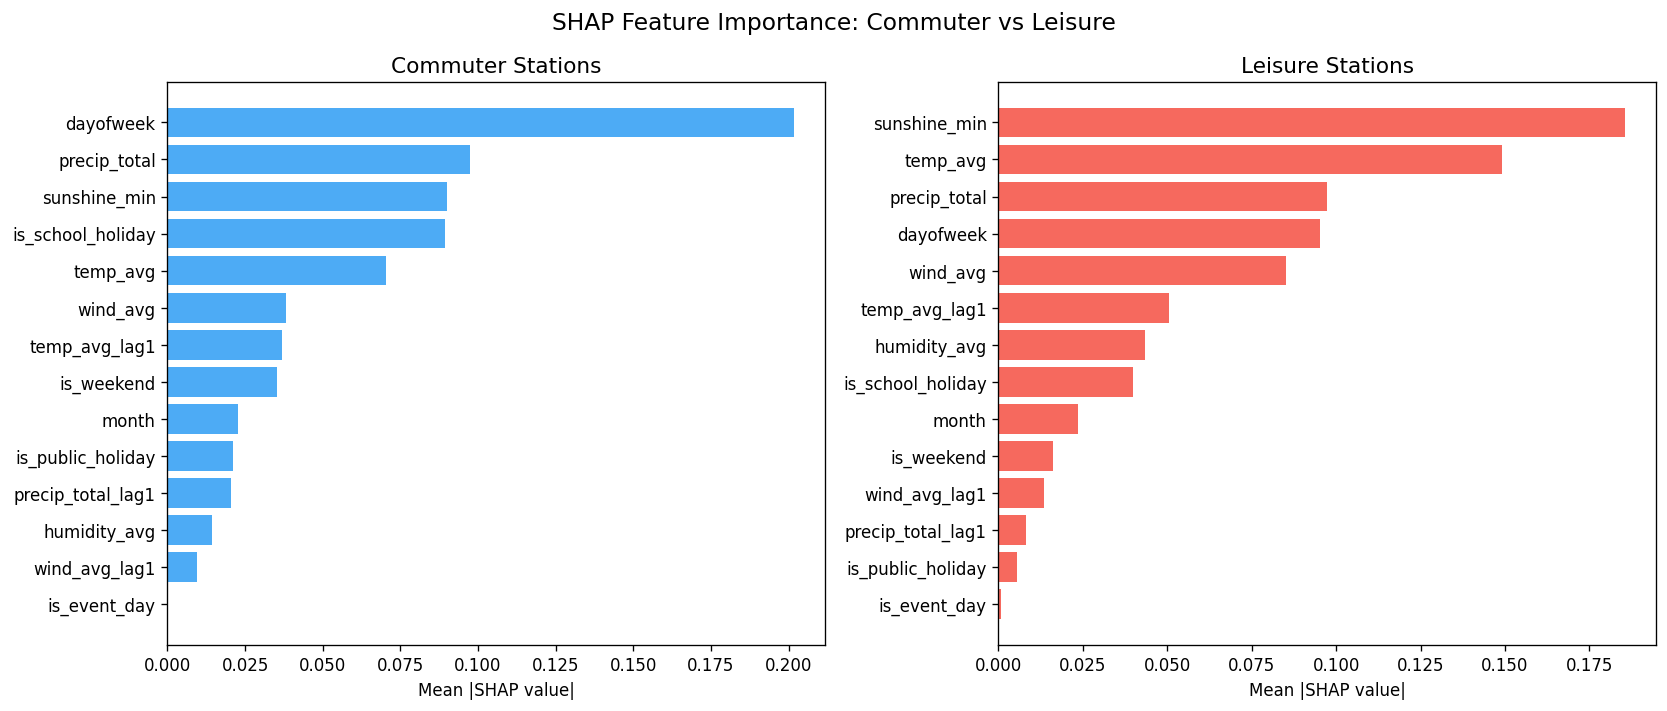

08c_shap_summary_comparison.png saved.


In [11]:
# Fig C — Commuter vs Leisure SHAP summary (side-by-side mean |SHAP| bar)
idx_shap_c = rng.choice(len(X_test_c), size=min(N_SHAP, len(X_test_c)), replace=False)
X_shap_c   = X_test_c[idx_shap_c]

idx_shap_l = rng.choice(len(X_test_l), size=min(N_SHAP, len(X_test_l)), replace=False)
X_shap_l   = X_test_l[idx_shap_l]

explainer_c   = shap.TreeExplainer(xgb_commuter)
shap_values_c = explainer_c.shap_values(X_shap_c)

explainer_l   = shap.TreeExplainer(xgb_leisure)
shap_values_l = explainer_l.shap_values(X_shap_l)

fig_c, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(14, 6))

for ax, shap_vals, title, color in [
    (ax_left,  shap_values_c, "Commuter Stations", COLORS["commuter"]),
    (ax_right, shap_values_l, "Leisure Stations",  COLORS["leisure"]),
]:
    mean_abs = np.abs(shap_vals).mean(axis=0)
    order = np.argsort(mean_abs)
    ax.barh(
        [ALL_FEATURES[i] for i in order],
        mean_abs[order],
        color=color,
        alpha=0.8,
    )
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_title(title, fontsize=13)

fig_c.suptitle("SHAP Feature Importance: Commuter vs Leisure", fontsize=14)
fig_c.tight_layout()
fig_c.savefig(FIGS / "08c_shap_summary_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("08c_shap_summary_comparison.png saved.")

## 7. Weather Effect Sizes

Reference: temp=15\u00b0C, precip=0mm, wind=10km/h, sunshine=300min, humidity=70%,
lag features same as reference, Wednesday (dayofweek=2), June, no calendar flags.

In [12]:
REF = {
    "temp_avg"         : 15.0,
    "precip_total"     : 0.0,
    "wind_avg"         : 10.0,
    "sunshine_min"     : 300.0,
    "humidity_avg"     : 70.0,
    "temp_avg_lag1"    : 15.0,
    "precip_total_lag1": 0.0,
    "wind_avg_lag1"    : 10.0,
    "dayofweek"        : 2,
    "month"            : 6,
    "is_weekend"       : 0,
    "is_public_holiday": 0,
    "is_school_holiday": 0,
    "is_event_day"     : 0,
}

median_offset_full = train_clean_full["site_offset"].median()
median_offset_c    = train_clean_c["site_offset"].median()
median_offset_l    = train_clean_l["site_offset"].median()

def weather_effect_xgb(model, feature, bad_val, ref_val, offset):
    base = np.array([[REF[f] for f in ALL_FEATURES]] * 100, dtype=float)
    feat_idx = ALL_FEATURES.index(feature)
    X_bad = base.copy(); X_bad[:, feat_idx] = bad_val
    X_ref = base.copy(); X_ref[:, feat_idx] = ref_val
    y_bad = np.expm1(model.predict(X_bad) + offset).mean()
    y_ref = np.expm1(model.predict(X_ref) + offset).mean()
    return (y_bad - y_ref) / y_ref * 100

comparisons = [
    ("Heavy rain (20mm vs 0mm)",    "precip_total",  20.0,   0.0),
    ("Light rain (2mm vs 0mm)",     "precip_total",   2.0,   0.0),
    ("Cold day (0\u00b0C vs 15\u00b0C)",      "temp_avg",       0.0,  15.0),
    ("Cool day (8\u00b0C vs 15\u00b0C)",      "temp_avg",       8.0,  15.0),
    ("Strong wind (40 vs 10 km/h)", "wind_avg",      40.0,  10.0),
    ("No sunshine (0 vs 300 min)",  "sunshine_min",   0.0, 300.0),
]

print("=" * 69)
print("XGBOOST WEATHER EFFECT SIZES")
print("=" * 69)
print(f"{'Condition':<35} | {'Full':>7} | {'Commuter':>9} | {'Leisure':>8}")
print("-" * 69)

eff_results = []
for label, feat, bad_val, ref_val in comparisons:
    eff_f = weather_effect_xgb(xgb_full,     feat, bad_val, ref_val, median_offset_full)
    eff_c = weather_effect_xgb(xgb_commuter, feat, bad_val, ref_val, median_offset_c)
    eff_l = weather_effect_xgb(xgb_leisure,  feat, bad_val, ref_val, median_offset_l)
    eff_results.append((label, eff_f, eff_c, eff_l))
    print(f"{label:<35} | {eff_f:>6.1f}% | {eff_c:>8.1f}% | {eff_l:>7.1f}%")

key_conditions = [
    ("Heavy rain (20mm vs 0mm)",    "Heavy rain (20mm)",     -33.6),
    ("Cold day (0\u00b0C vs 15\u00b0C)",     "Cold day (0\u00b0C)",         -37.1),
    ("Strong wind (40 vs 10 km/h)", "Strong wind (40 km/h)", -58.8),
]
eff_dict = {label: eff_f for label, eff_f, _, _ in eff_results}

print("\n" + "=" * 57)
print("GAM vs XGBOOST EFFECT SIZE COMPARISON (Full model)")
print("=" * 57)
print(f"{'Condition':<25} | {'GAM':>8} | {'XGBoost':>9} | {'Diff':>8}")
print("-" * 57)
for full_label, short, gam_v in key_conditions:
    eff_f = eff_dict[full_label]
    print(f"{short:<25} | {gam_v:>7.1f}% | {eff_f:>8.1f}% | {eff_f - gam_v:>+7.1f}%")
print("=" * 57)

XGBOOST WEATHER EFFECT SIZES
Condition                           |    Full |  Commuter |  Leisure
---------------------------------------------------------------------
Heavy rain (20mm vs 0mm)            |  -36.3% |    -32.7% |   -32.8%
Light rain (2mm vs 0mm)             |  -15.1% |    -11.6% |   -18.1%
Cold day (0°C vs 15°C)              |  -26.4% |    -22.9% |   -39.3%
Cool day (8°C vs 15°C)              |  -14.6% |     -7.6% |   -20.8%
Strong wind (40 vs 10 km/h)         |  -53.8% |    -11.3% |   -53.3%
No sunshine (0 vs 300 min)          |  -13.0% |     -8.4% |   -24.4%

GAM vs XGBOOST EFFECT SIZE COMPARISON (Full model)
Condition                 |      GAM |   XGBoost |     Diff
---------------------------------------------------------
Heavy rain (20mm)         |   -33.6% |    -36.3% |    -2.7%
Cold day (0°C)            |   -37.1% |    -26.4% |   +10.7%
Strong wind (40 km/h)     |   -58.8% |    -53.8% |    +5.0%


## 8. Normalized Cycling Index

Replace actual weather with reference conditions; predict with Full XGBoost.
The normalized count shows underlying demand stripped of weather variation.

Saved: normalized_cycling_index_xgb.csv


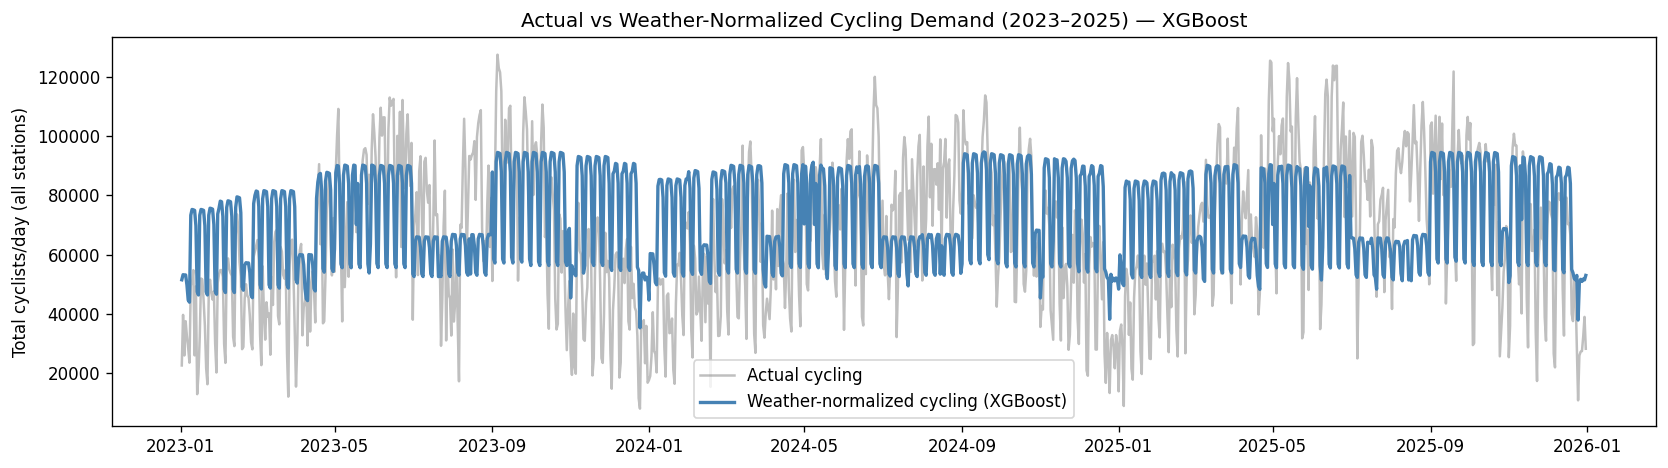

08c_normalized_vs_actual.png saved.


In [13]:
REF_WEATHER = {
    "temp_avg"         : 15.0,
    "precip_total"     : 0.0,
    "wind_avg"         : 10.0,
    "sunshine_min"     : 300.0,
    "humidity_avg"     : 70.0,
    "temp_avg_lag1"    : 15.0,
    "precip_total_lag1": 0.0,
    "wind_avg_lag1"    : 10.0,
}

panel_norm = panel_good.copy()
panel_norm["date"] = pd.to_datetime(panel_norm["date"])
for col in ["is_weekend", "is_public_holiday", "is_school_holiday", "is_event_day"]:
    panel_norm[col] = panel_norm[col].astype(int)

cols_needed  = ALL_FEATURES + ["site_offset"]
extra_cols   = ["site ID", "naam", "date", "aantal", "site_type", "day_type", "season"]
avail_extra  = [c for c in extra_cols if c in panel_norm.columns]
panel_norm_clean = panel_norm[cols_needed + avail_extra].dropna(subset=cols_needed)

X_norm = panel_norm_clean[ALL_FEATURES].values.copy().astype(float)
for feat, val in REF_WEATHER.items():
    X_norm[:, ALL_FEATURES.index(feat)] = val

offset = panel_norm_clean["site_offset"].values
y_adj_pred = xgb_full.predict(X_norm)
panel_norm_clean = panel_norm_clean.copy()
panel_norm_clean["normalized_count"] = np.clip(np.expm1(y_adj_pred + offset), 0, None)

out_cols = ["site ID", "naam", "date", "aantal", "normalized_count"] + \
           [c for c in ["site_type", "day_type", "season"] if c in panel_norm_clean.columns]
panel_norm_clean[out_cols].to_csv(
    PROCESSED / "normalized_cycling_index_xgb.csv", index=False
)
print("Saved: normalized_cycling_index_xgb.csv")

daily_actual = panel_norm_clean.groupby("date")["aantal"].sum()
daily_norm   = panel_norm_clean.groupby("date")["normalized_count"].sum()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_actual.index, daily_actual.values, alpha=0.5, color="gray", label="Actual cycling")
ax.plot(daily_norm.index,   daily_norm.values,   color="steelblue", linewidth=2,
        label="Weather-normalized cycling (XGBoost)")
ax.set_title("Actual vs Weather-Normalized Cycling Demand (2023\u20132025) \u2014 XGBoost")
ax.set_ylabel("Total cyclists/day (all stations)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGS / "08c_normalized_vs_actual.png", dpi=150)
plt.show()
print("08c_normalized_vs_actual.png saved.")

## 9. Save Models

In [14]:
models = {
    "xgb_full"     : xgb_full,
    "xgb_commuter" : xgb_commuter,
    "xgb_leisure"  : xgb_leisure,
    "site_log_mean": site_log_mean,
    "ALL_FEATURES" : ALL_FEATURES,
}
with open(PROCESSED / "xgb_models.pkl", "wb") as fh:
    pickle.dump(models, fh)
print(f"Models saved to {PROCESSED / 'xgb_models.pkl'}")

Models saved to /Users/queena/Documents/KU Leuven/Study material/Semester 1.2/Modern Analysis/Project/mda-cycling-weather-group6/data/processed/xgb_models.pkl


## 10. Final Summary

In [15]:
heavy_rain  = weather_effect_xgb(xgb_full, "precip_total",  20.0,   0.0, median_offset_full)
cold_day    = weather_effect_xgb(xgb_full, "temp_avg",       0.0,  15.0, median_offset_full)
strong_wind = weather_effect_xgb(xgb_full, "wind_avg",      40.0,  10.0, median_offset_full)

print("=" * 54)
print("XGBOOST MODELLING SUMMARY")
print("=" * 54)
print(f"Training period : 2023\u20132024 ({len(y_train_full):,} observations)")
print(f"Test period     : 2025     ({len(y_test_full):,} observations)")
print()
print("Model performance (test set):")
print(f"  Full XGB     : MAE={test_mae:.1f}, R\u00b2={test_r2:.3f}")
print(f"  Commuter XGB : MAE={mae_c:.1f}, R\u00b2={r2_c:.3f}")
print(f"  Leisure XGB  : MAE={mae_l:.1f}, R\u00b2={r2_l:.3f}")
print()
print("Improvement over GAM:")
print(f"  Full     : \u0394R\u00b2 = {test_r2 - 0.784:+.3f}")
print(f"  Commuter : \u0394R\u00b2 = {r2_c - 0.779:+.3f}")
print(f"  Leisure  : \u0394R\u00b2 = {r2_l - 0.626:+.3f}")
print()
print("Key weather effects (full model):")
print(f"  Heavy rain (20mm) : {heavy_rain:+.1f}%")
print(f"  Cold day (0\u00b0C)    : {cold_day:+.1f}%")
print(f"  Strong wind       : {strong_wind:+.1f}%")
print("=" * 54)

XGBOOST MODELLING SUMMARY
Training period : 2023–2024 (96,038 observations)
Test period     : 2025     (48,151 observations)

Model performance (test set):
  Full XGB     : MAE=152.7, R²=0.787
  Commuter XGB : MAE=136.4, R²=0.775
  Leisure XGB  : MAE=174.2, R²=0.663

Improvement over GAM:
  Full     : ΔR² = +0.003
  Commuter : ΔR² = -0.004
  Leisure  : ΔR² = +0.037

Key weather effects (full model):
  Heavy rain (20mm) : -36.3%
  Cold day (0°C)    : -26.4%
  Strong wind       : -53.8%
